# 비지도학습 군집분석: 정답지가 없는 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/shopping-data.csv")
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# 군집분석(계층적 군집, 비계층적 군집)
* 계층적 군집
    * 비지도학습
    * 데이터가 적을 때 사용
    * 거리 계산 지표: 유크리드, 맨하튼, 코사인 유사도
* 계층적 군집 5가지
    * 단일연결법(single linage), 최단연결법: 군집과 군집 사이에서 가장 가까운 데이터를 기준으로 묶음
    * 완전연결법(complite linage), 최장연결법: 군집과 군집 사이에서 가장 먼 데이터를 기준으로 묶음
    * 평균연결법(average linkage): 군집과 군집 사이의 모든 데이터의 평균 데이터로 계산(이상칯에 덜 민감)
    * 중심연결법(centroid linkage): 군집과 중심점 사이의 거리르 거리로 측정한 방법, 계산이 빠름
    * 와드연결법(ward linkage): 군집내 오차가 최소가 되는 데이터로 계산, 군집내 분산이 최소, 조밀한 군집
* 계층적 군집의 시각화는 덴드로그램으로 한다.

In [4]:
import scipy.cluster.hierarchy as shc

In [5]:
data = pd.get_dummies(data, drop_first=True)
data

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False
...,...,...,...,...,...
195,196,35,120,79,False
196,197,45,126,28,False
197,198,32,126,74,True
198,199,32,137,18,True


In [6]:
data2 = data.copy()

In [7]:
data = data.drop('CustomerID', axis=1)
data

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False
...,...,...,...,...
195,35,120,79,False
196,45,126,28,False
197,32,126,74,True
198,32,137,18,True


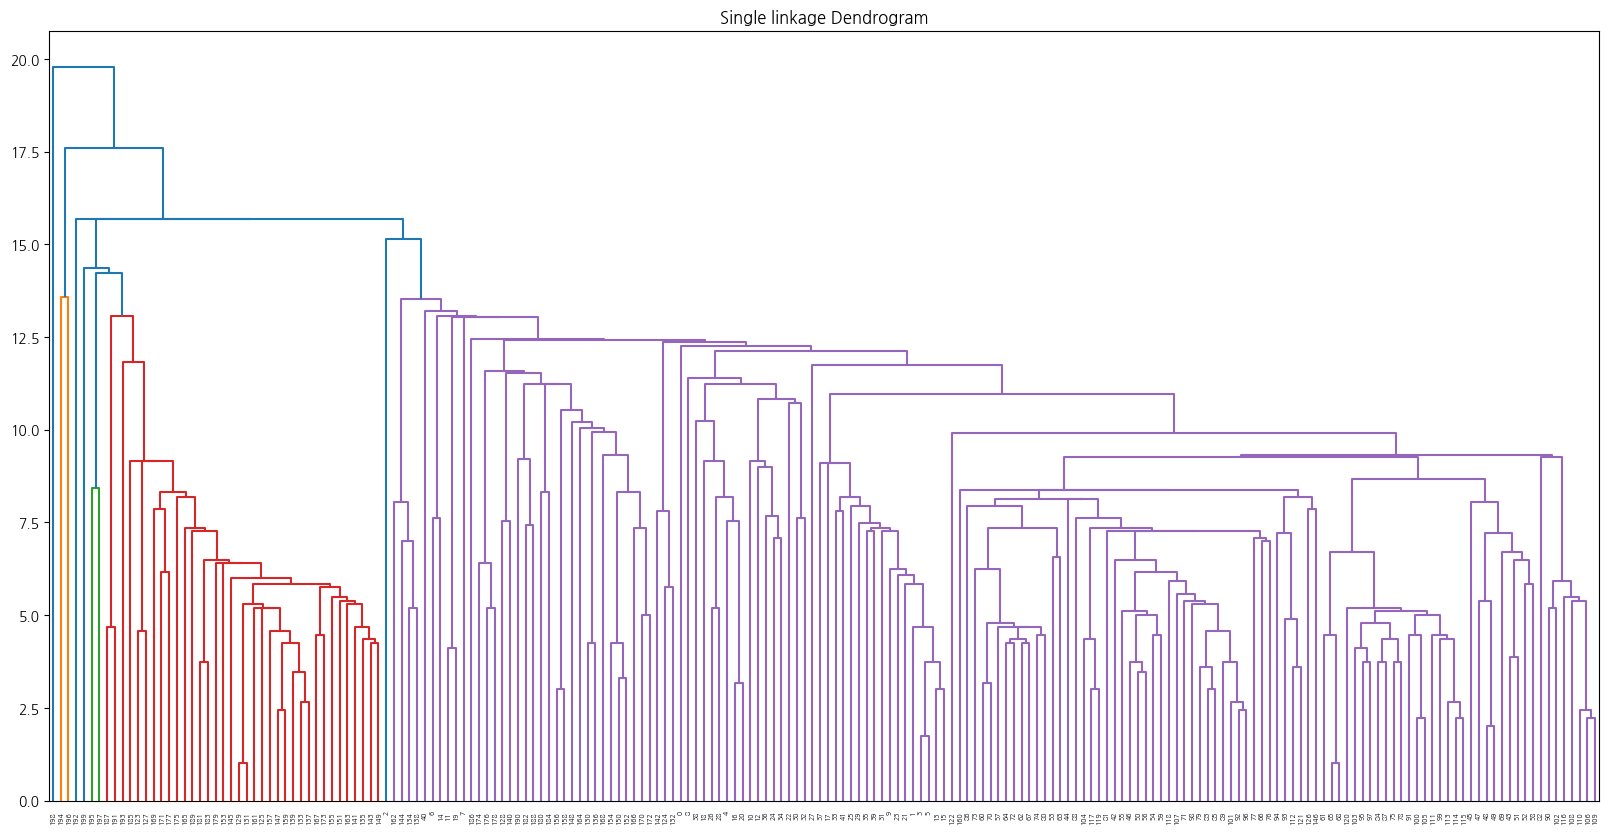

In [8]:
plt.figure(figsize=(20, 10))
plt.title('Single linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(data, method='single'))
plt.show()

완전연결법/최장연결법

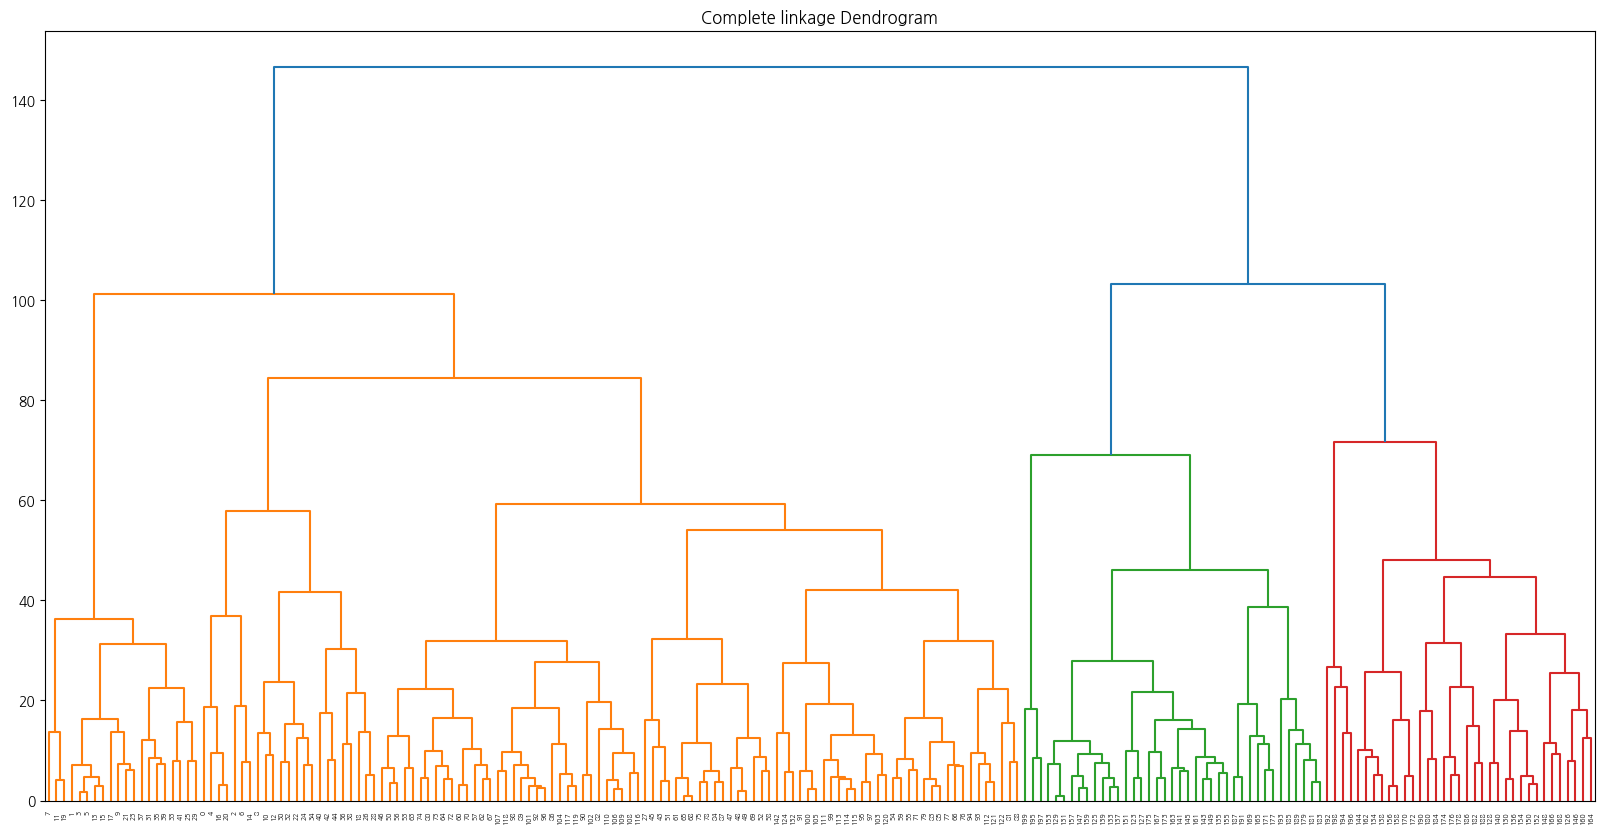

In [9]:
plt.figure(figsize=(20, 10))
plt.title('Complete linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(data, method='complete'))
plt.show()

평균연결법

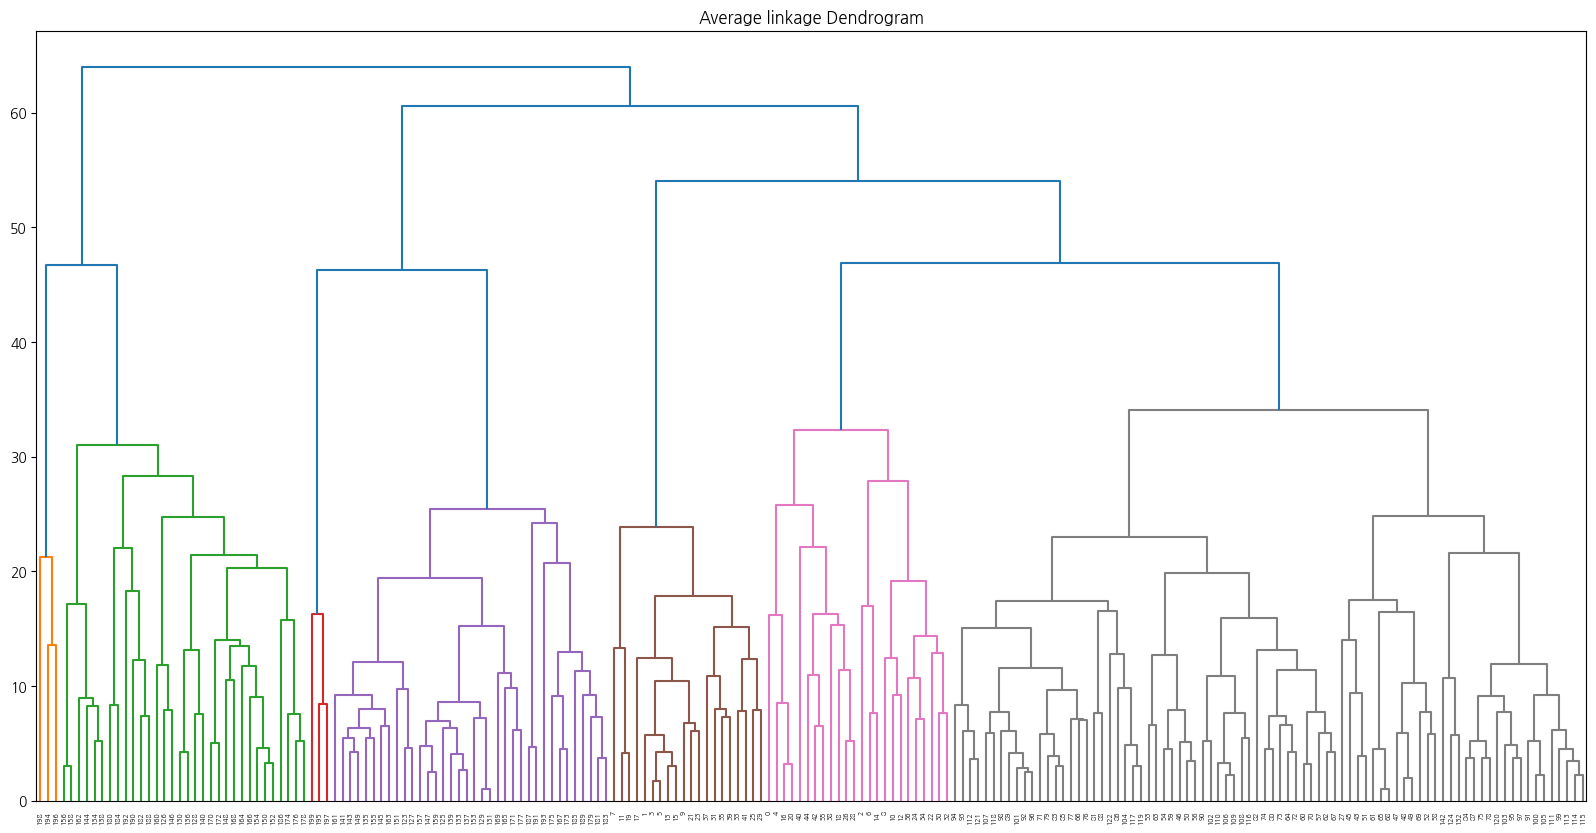

In [10]:
plt.figure(figsize=(20, 10))
plt.title('Average linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(data, method='average'))
plt.show()

중심연결법

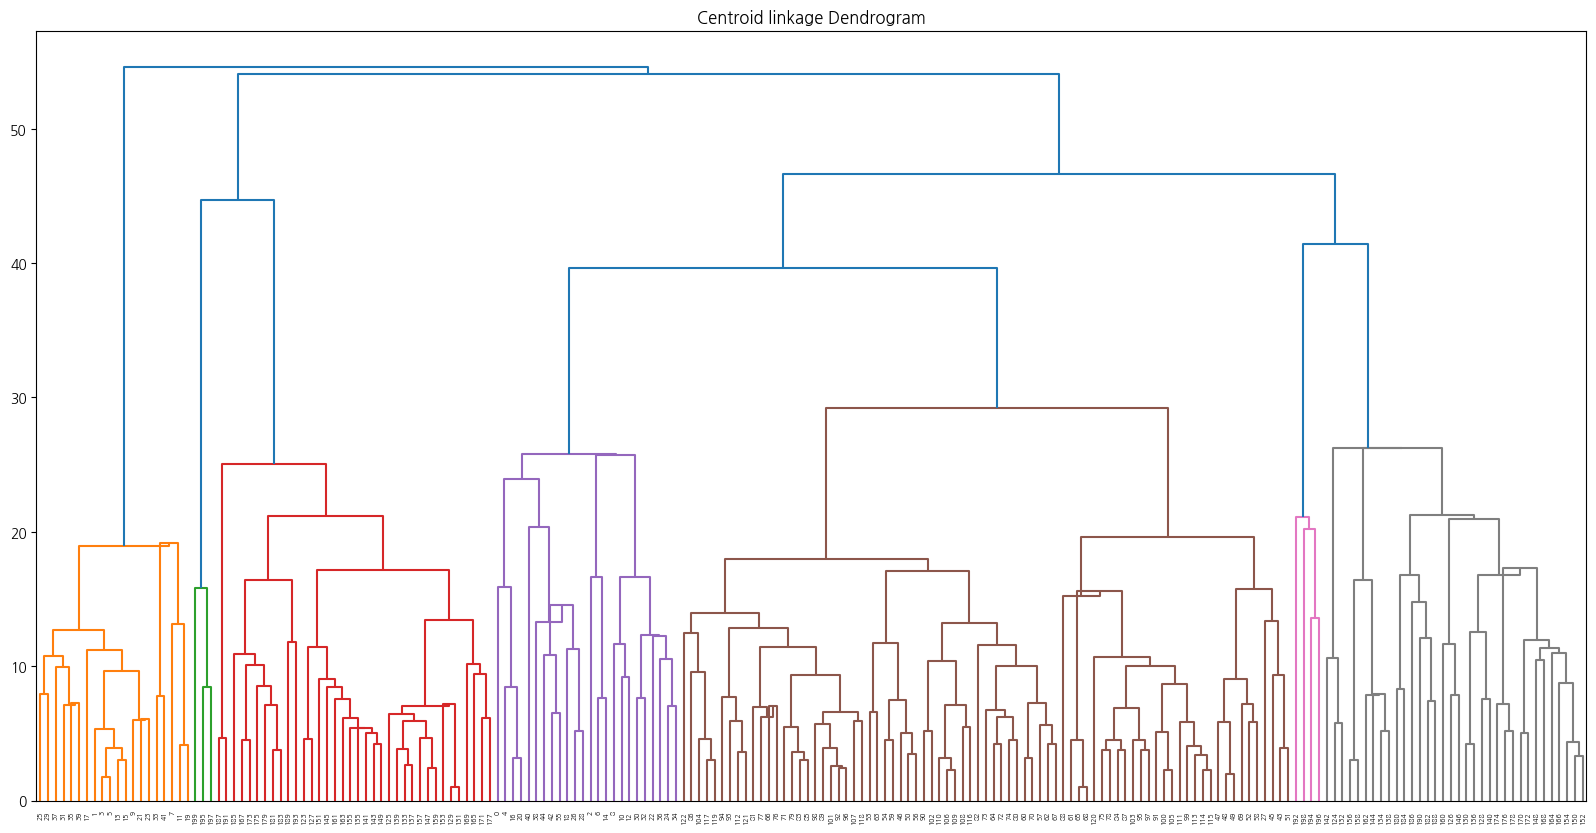

In [11]:
plt.figure(figsize=(20, 10))
plt.title('Centroid linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(data, method='centroid'))
plt.show()

와드연결법

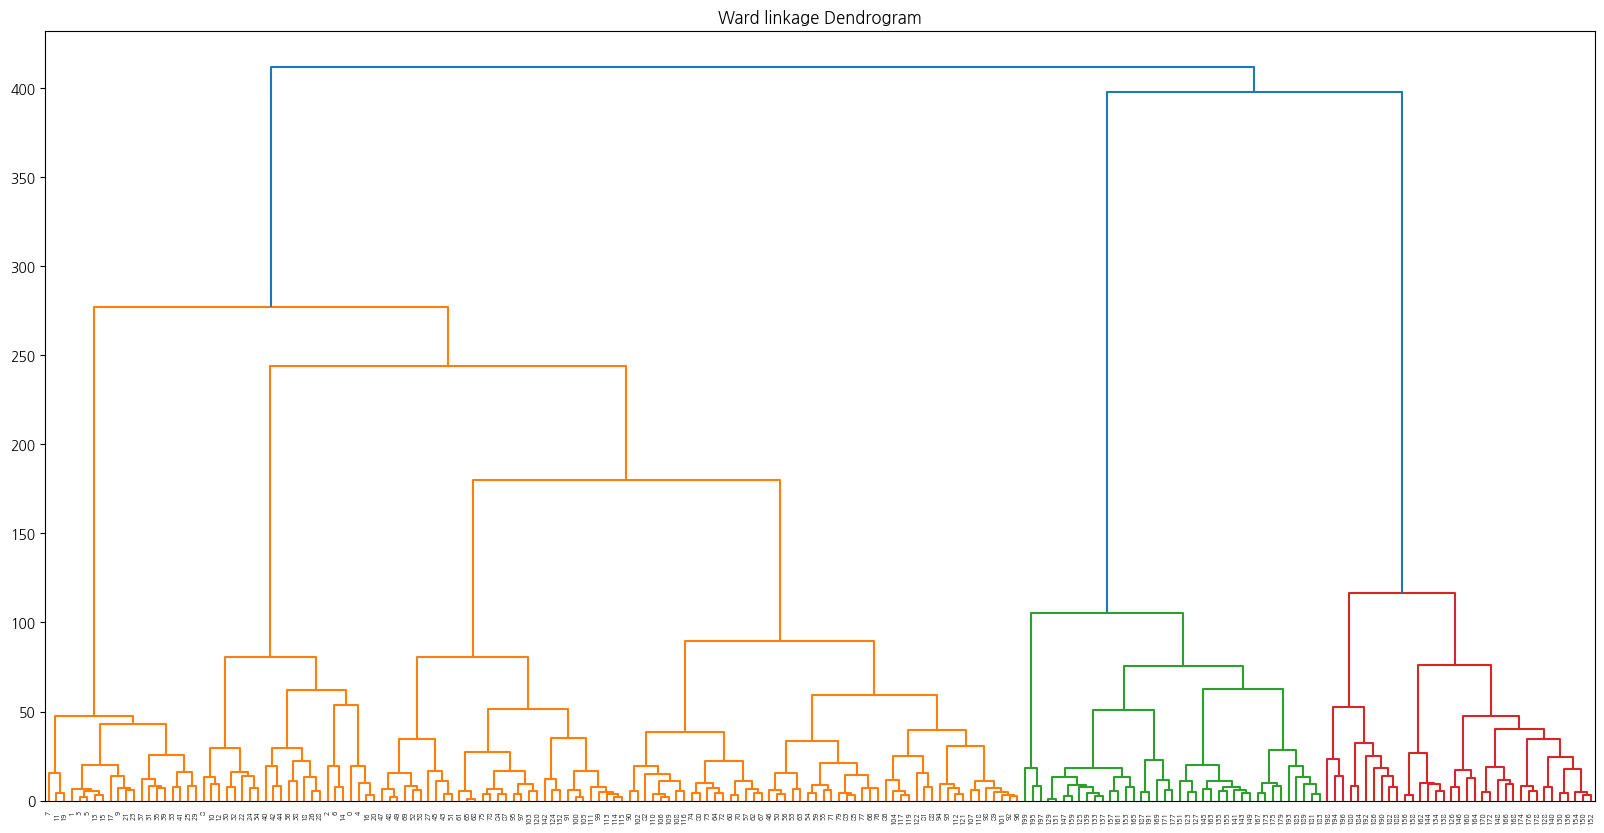

In [12]:
plt.figure(figsize=(20, 10))
plt.title('Ward linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(data, method='ward'))
plt.show()

In [13]:
from sklearn.cluster import AgglomerativeClustering

In [14]:
single = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='single')
result = single.fit_predict(data)
result

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0,
       1, 0])

In [15]:
data2['single'] = result
data2

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single
0,1,19,15,39,True,0
1,2,21,15,81,True,0
2,3,20,16,6,False,0
3,4,23,16,77,False,0
4,5,31,17,40,False,0
...,...,...,...,...,...,...
195,196,35,120,79,False,0
196,197,45,126,28,False,2
197,198,32,126,74,True,0
198,199,32,137,18,True,1


In [16]:
average = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='average')
result = average.fit_predict(data)
data2['average'] = result
data2

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,average
0,1,19,15,39,True,0,0
1,2,21,15,81,True,0,0
2,3,20,16,6,False,0,0
3,4,23,16,77,False,0,0
4,5,31,17,40,False,0,0
...,...,...,...,...,...,...,...
195,196,35,120,79,False,0,2
196,197,45,126,28,False,2,1
197,198,32,126,74,True,0,2
198,199,32,137,18,True,1,1


In [17]:
ward = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
result = average.fit_predict(data)
data2['ward'] = result
data2

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,average,ward
0,1,19,15,39,True,0,0,0
1,2,21,15,81,True,0,0,0
2,3,20,16,6,False,0,0,0
3,4,23,16,77,False,0,0,0
4,5,31,17,40,False,0,0,0
...,...,...,...,...,...,...,...,...
195,196,35,120,79,False,0,2,2
196,197,45,126,28,False,2,1,1
197,198,32,126,74,True,0,2,2
198,199,32,137,18,True,1,1,1


In [20]:
data2[data2['single'] == 2]

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,average,ward
194,195,47,120,16,False,2,1,1
196,197,45,126,28,False,2,1,1


In [21]:
data2[data2['average'] == 1]

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,average,ward
126,127,43,71,35,True,0,1,1
128,129,59,71,11,True,0,1,1
130,131,47,71,9,True,0,1,1
134,135,20,73,5,True,0,1,1
136,137,44,73,7,False,0,1,1
138,139,19,74,10,True,0,1,1
140,141,57,75,5,False,0,1,1
144,145,25,77,12,True,0,1,1
146,147,48,77,36,True,0,1,1
148,149,34,78,22,False,0,1,1


# 비계층적 군집 - 데이터 수가 많을 때 사용
* k-means(k 평균 군집): 거리를 기준으로 군집을 형성, 이상치에 민감함
* StandardScaler를 사용 데이터에 이상치가 있으면 RobustScaler
* 평균이 아닌 중앙값을 이용해서 군집 형성

In [4]:
data = pd.read_csv("./data/06고객이탈예측.csv", encoding="cp949")
data

,회원ID,성별,고연령,배우자,피부양자,가입기간,전화서비스,2회선이상,인터넷서비스,온라인보안,...,기기보호서비스,기술지원,스트리밍TV,스트리밍Movies,약정옵션,온라인고지서,지불수단,월요금,합산요금,이탈여부
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   회원ID        7043 non-null   object 
 1   성별          7043 non-null   object 
 2   고연령         7043 non-null   int64  
 3   배우자         7043 non-null   object 
 4   피부양자        7043 non-null   object 
 5   가입기간        7043 non-null   int64  
 6   전화서비스       7043 non-null   object 
 7   2회선이상       7043 non-null   object 
 8   인터넷서비스      7043 non-null   object 
 9   온라인보안       7043 non-null   object 
 10  온라인백업       7043 non-null   object 
 11  기기보호서비스     7043 non-null   object 
 12  기술지원        7043 non-null   object 
 13  스트리밍TV      7043 non-null   object 
 14  스트리밍Movies  7043 non-null   object 
 15  약정옵션        7043 non-null   object 
 16  온라인고지서      7043 non-null   object 
 17  지불수단        7043 non-null   object 
 18  월요금         7043 non-null   float64
 19  합산요금        7043 non-null  

In [15]:
data['합산요금'] = data['합산요금'].replace(" ", "0").replace("", "0").astype('float')
data['합산요금']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: 합산요금, Length: 7043, dtype: float64

In [6]:
data.describe()

,고연령,가입기간,월요금
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
data2 = data.copy()

In [8]:
data = data.drop('회원ID', axis=1)
data

,성별,고연령,배우자,피부양자,가입기간,전화서비스,2회선이상,인터넷서비스,온라인보안,온라인백업,기기보호서비스,기술지원,스트리밍TV,스트리밍Movies,약정옵션,온라인고지서,지불수단,월요금,합산요금,이탈여부
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [18]:
num_cols = data[['가입기간', '월요금', '합산요금']]
cat_cols = data.drop(['가입기간', '월요금', '합산요금'], axis=1)

In [19]:
num_cols.columns

Index(['가입기간', '월요금', '합산요금'], dtype='object')

In [20]:
cat_cols.columns

Index(['성별', '고연령', '배우자', '피부양자', '전화서비스', '2회선이상', '인터넷서비스', '온라인보안',
       '온라인백업', '기기보호서비스', '기술지원', '스트리밍TV', '스트리밍Movies', '약정옵션', '온라인고지서',
       '지불수단', '이탈여부'],
      dtype='object')

In [21]:
from sklearn.preprocessing import StandardScaler

In [23]:
ss = StandardScaler()
ss_cols = ss.fit_transform(num_cols)
ss_cols = pd.DataFrame(ss_cols, columns=num_cols.columns, index=num_cols.index)
ss_cols

,가입기간,월요금,합산요금
0,-1.277445,-1.160323,-0.992611
1,0.066327,-0.259629,-0.172165
2,-1.236724,-0.362660,-0.958066
3,0.514251,-0.746535,-0.193672
4,-1.236724,0.197365,-0.938874
...,...,...,...
7038,-0.340876,0.665992,-0.127605
7039,1.613701,1.277533,2.242606
7040,-0.870241,-1.168632,-0.852932
7041,-1.155283,0.320338,-0.870513


In [25]:
ss_data = pd.concat([cat_cols, ss_cols], axis=1)
ss_data

,성별,고연령,배우자,피부양자,전화서비스,2회선이상,인터넷서비스,온라인보안,온라인백업,기기보호서비스,기술지원,스트리밍TV,스트리밍Movies,약정옵션,온라인고지서,지불수단,이탈여부,가입기간,월요금,합산요금
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No,-1.277445,-1.160323,-0.992611
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No,0.066327,-0.259629,-0.172165
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,-1.236724,-0.362660,-0.958066
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No,0.514251,-0.746535,-0.193672
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes,-1.236724,0.197365,-0.938874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No,-0.340876,0.665992,-0.127605
7039,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No,1.613701,1.277533,2.242606
7040,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,-0.870241,-1.168632,-0.852932
7041,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,-1.155283,0.320338,-0.870513


In [27]:
ss_data = pd.get_dummies(ss_data, drop_first=True)
ss_data

,고연령,가입기간,월요금,합산요금,성별_Female,성별_Male,배우자_No,배우자_Yes,피부양자_No,피부양자_Yes,...,약정옵션_One year,약정옵션_Two year,온라인고지서_No,온라인고지서_Yes,지불수단_Bank transfer (automatic),지불수단_Credit card (automatic),지불수단_Electronic check,지불수단_Mailed check,이탈여부_No,이탈여부_Yes
0,0,-1.277445,-1.160323,-0.992611,True,False,False,True,True,False,...,False,False,False,True,False,False,True,False,True,False
1,0,0.066327,-0.259629,-0.172165,False,True,True,False,True,False,...,True,False,True,False,False,False,False,True,True,False
2,0,-1.236724,-0.362660,-0.958066,False,True,True,False,True,False,...,False,False,False,True,False,False,False,True,False,True
3,0,0.514251,-0.746535,-0.193672,False,True,True,False,True,False,...,True,False,True,False,True,False,False,False,True,False
4,0,-1.236724,0.197365,-0.938874,True,False,True,False,True,False,...,False,False,False,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,-0.340876,0.665992,-0.127605,False,True,False,True,False,True,...,True,False,False,True,False,False,False,True,True,False
7039,0,1.613701,1.277533,2.242606,True,False,False,True,False,True,...,True,False,False,True,False,True,False,False,True,False
7040,0,-0.870241,-1.168632,-0.852932,True,False,False,True,False,True,...,False,False,False,True,False,False,True,False,True,False
7041,1,-1.155283,0.320338,-0.870513,False,True,False,True,True,False,...,False,False,False,True,False,False,False,True,False,True


kmeans로 군집 분석하기

In [28]:
from sklearn.cluster import KMeans

In [29]:
km = KMeans(random_state=42)
km.fit(ss_data)
result = km.labels_
result

array([4, 7, 7, ..., 4, 5, 6], dtype=int32)

In [30]:
data2['cluster'] = result
data2

,회원ID,성별,고연령,배우자,피부양자,가입기간,전화서비스,2회선이상,인터넷서비스,온라인보안,...,기술지원,스트리밍TV,스트리밍Movies,약정옵션,온라인고지서,지불수단,월요금,합산요금,이탈여부,cluster
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,4
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,7
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,7
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,6
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,4
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes,5


In [31]:
data2['cluster'].value_counts()

cluster
2    1526
5     936
3     903
7     881
0     824
1     772
6     704
4     497
Name: count, dtype: int64

In [32]:
data2[data2['cluster'] == 0]['이탈여부'].value_counts()

이탈여부
No     785
Yes     39
Name: count, dtype: int64

In [33]:
data2['이탈여부'].value_counts()

이탈여부
No     5174
Yes    1869
Name: count, dtype: int64

In [34]:
data2[data2['cluster'] == 1]['월요금'].describe()

count    772.000000
mean      93.321114
std        7.477588
min       64.750000
25%       89.100000
50%       94.100000
75%       98.925000
max      112.950000
Name: 월요금, dtype: float64

In [35]:
km = KMeans(n_clusters=3, random_state=42)
km.fit(ss_data)
result = km.labels_
data2['cluster'] = result

In [36]:
data2

,회원ID,성별,고연령,배우자,피부양자,가입기간,전화서비스,2회선이상,인터넷서비스,온라인보안,...,기술지원,스트리밍TV,스트리밍Movies,약정옵션,온라인고지서,지불수단,월요금,합산요금,이탈여부,cluster
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,1
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes,1


In [39]:
data2[data2['cluster']==0]['월요금'].describe()

count    2333.000000
mean       88.775889
std        18.223031
min        35.700000
25%        76.350000
50%        92.000000
75%       104.050000
max       118.750000
Name: 월요금, dtype: float64

In [38]:
data2[data2['cluster']==1]

,회원ID,성별,고연령,배우자,피부양자,가입기간,전화서비스,2회선이상,인터넷서비스,온라인보안,...,기술지원,스트리밍TV,스트리밍Movies,약정옵션,온라인고지서,지불수단,월요금,합산요금,이탈여부,cluster
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No,1
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No,1
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No,1
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,1


# 군집의 최적 개수 정하기 
* elbow method
* 실루엣 지수
* 군집분석의 응집도(요소들이 얼마나 모여있는지 판단하는 지표)
    * inertia_ 값이 작을수록 군집이 잘 형성됨
* elbow method: inertia_(응집도)를 출력하고 시각화한 뒤 응집도의 감소폭이 금격한 변화가 시작되는 지점을 군집의 수로 채택하는 방법

In [40]:
print(km.inertia_)

52063.5709979504


In [42]:
inertia = []
for i in range(1, 21):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(ss_data)
    inertia.append(km.inertia_)
inertia

[84423.62331392875,
 65368.86039354423,
 52063.5709979504,
 48164.746570248455,
 45800.294336385465,
 44285.754342974804,
 43019.784009964715,
 42068.36731633097,
 40283.86794237345,
 39668.69102279282,
 38874.11928050567,
 38129.555075469085,
 37530.7972211299,
 37104.708733170395,
 36676.804990773,
 36310.30929972753,
 35964.166337497925,
 35564.36666415465,
 35240.72855630824,
 34928.50741302883]

엘보우 메소드로 계산한 최적 군집 수: 3개

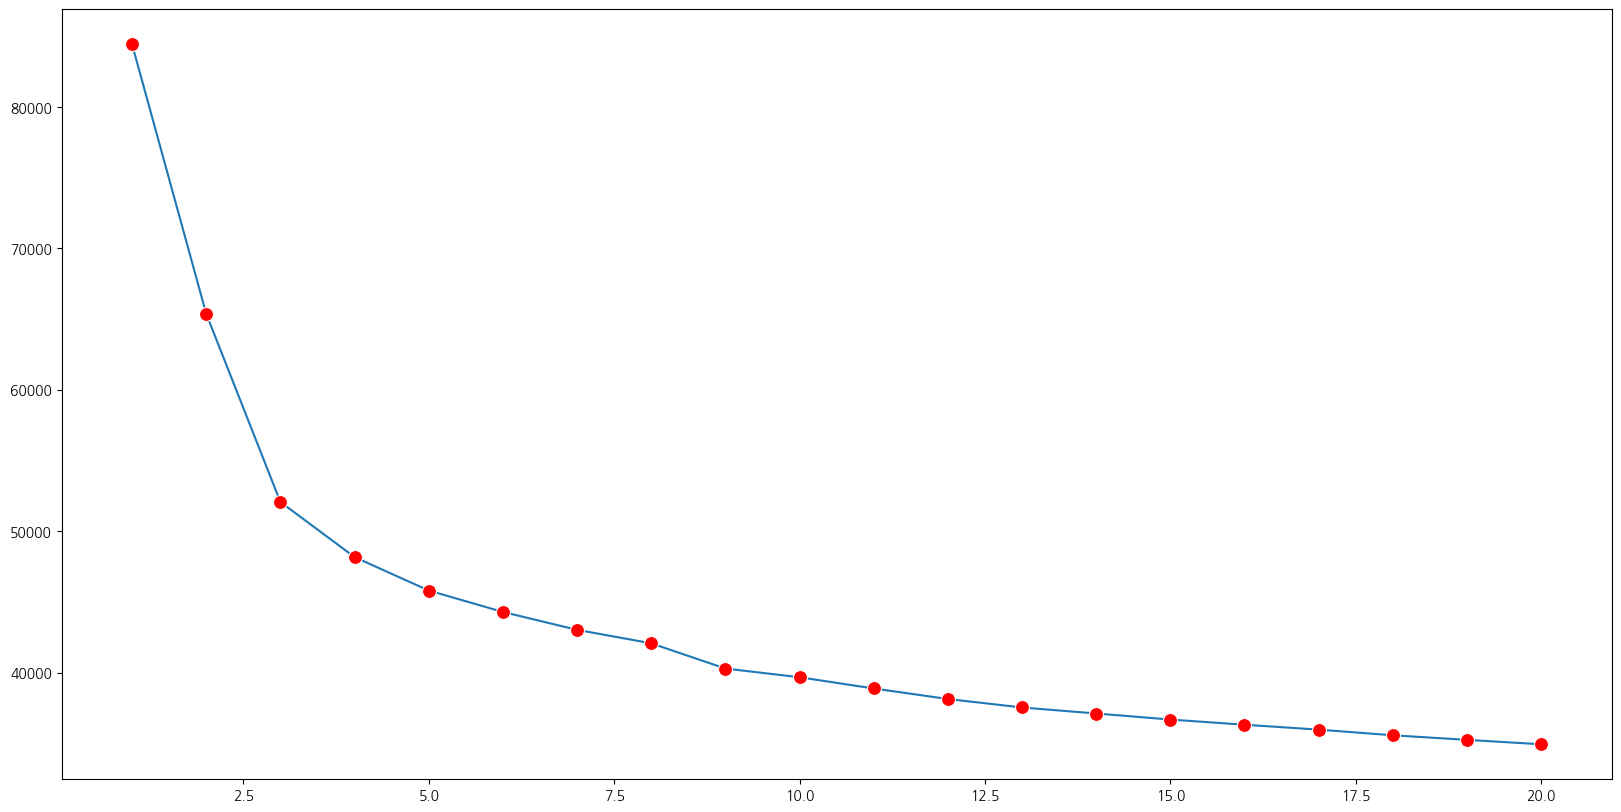

In [46]:
plt.figure(figsize=(20, 10))
sns.lineplot(x=range(1, 21), y=inertia, marker='o', markersize=10, markerfacecolor='red')
plt.show()

* 실루엣 지수를 출력해서 최적 군집 개수 구하기
* 실루엣 지수를 구하기 위해서는 최소 2개 이상의 군집이 필요
* 실루엣 점수가 가장 높은 클러스터 개수가 최적 군집 개수

In [44]:
from sklearn.metrics import silhouette_score

In [45]:
sil_scores = []
for i in range(2, 21):
    km2 = KMeans(n_clusters=i, random_state=42)
    km2.fit(ss_data)
    labels = km2.labels_
    sil_scores.append(silhouette_score(ss_data, labels))
sil_scores

[np.float64(0.24656564532427477),
 np.float64(0.24811637322209545),
 np.float64(0.20559453941157116),
 np.float64(0.18600858855020616),
 np.float64(0.16787525232463285),
 np.float64(0.16582702370623253),
 np.float64(0.1518301196517904),
 np.float64(0.11561278294081716),
 np.float64(0.10655332475119654),
 np.float64(0.10355047558682844),
 np.float64(0.10513352547849117),
 np.float64(0.10506335936533594),
 np.float64(0.10303461734707596),
 np.float64(0.10230072668619496),
 np.float64(0.10125518224084407),
 np.float64(0.09843169894691094),
 np.float64(0.09726971029115289),
 np.float64(0.09774514758524674),
 np.float64(0.0904402940668998)]

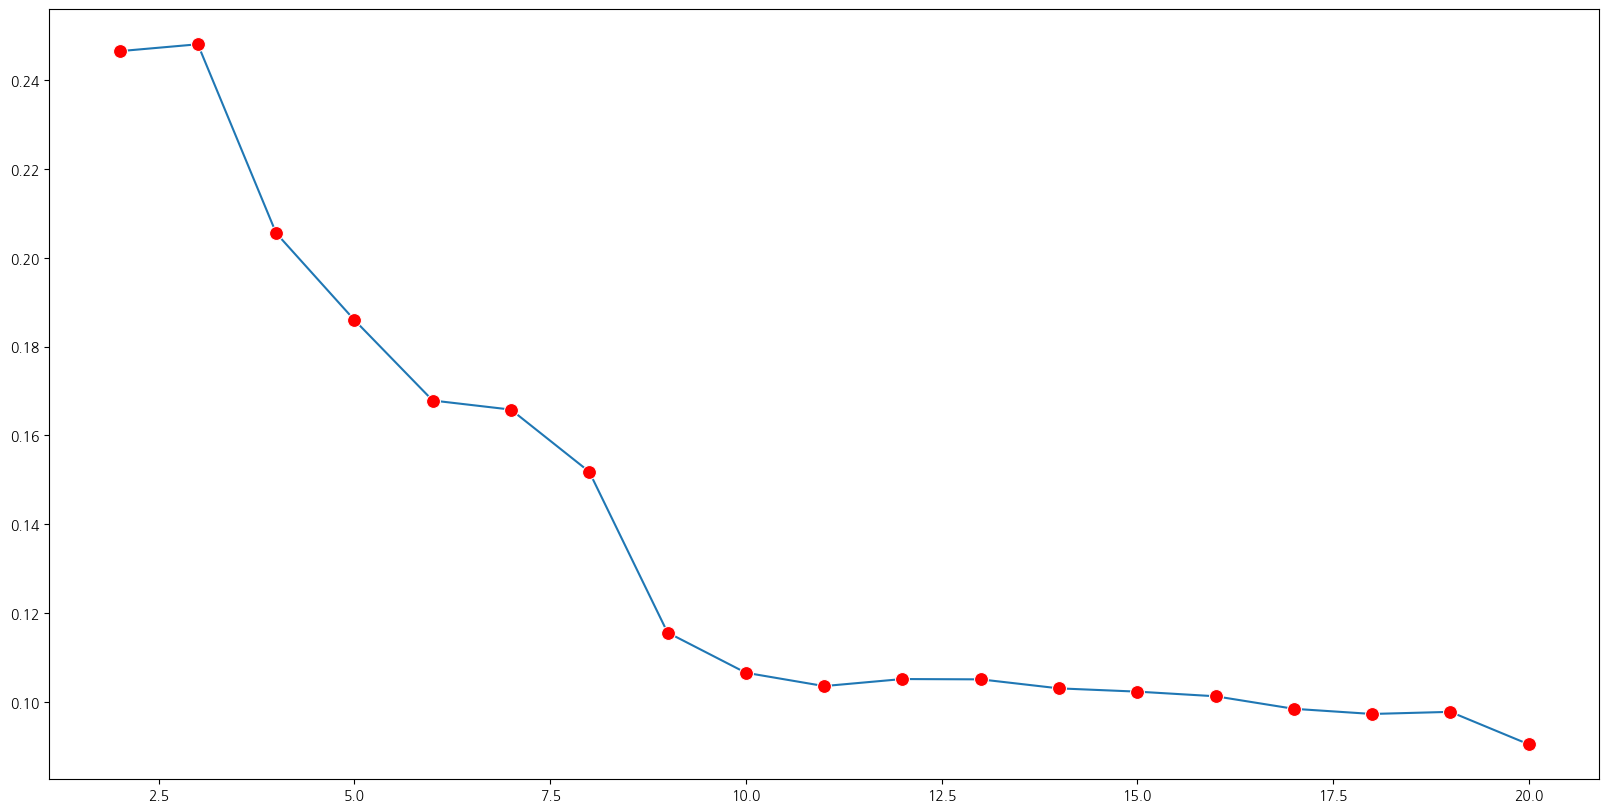

In [48]:
plt.figure(figsize=(20, 10))
sns.lineplot(x=range(2, 21), y=sil_scores, marker='o', markersize=10, markerfacecolor='red')
plt.show()